## Airline Passenger Prediction Satisfaction

## STEP 1: PROBLEM DEFINITION

Predicting passenger satisfaction can significantly benefit the airline industry by enabling airlines to proactively address customer needs, 
optimize services, and enhance overall travel experiences. By leveraging data analytics and machine learning to forecast satisfaction levels, 
airlines can identify pain points—such as delays, baggage issues, or in-flight service gaps—and implement targeted improvements. 
This leads to increased customer loyalty, higher retention rates, and positive word-of-mouth, which can boost revenue. Additionally, 
predictive insights allow airlines to allocate resources efficiently, streamline operations, and stay competitive in a customer-centric market, 
ultimately improving profitability and brand reputation. Predicting passenger satisfaction helps airlines make customers happier. By using data to guess what travelers want, airlines can fix problems like delays or bad service. This makes passengers more loyal, brings in more money, and improves the airline’s reputation. It also helps airlines use resources better and stay ahead of competitors.

## STEP 2: DATA COLLECTION

In [21]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import xgboost as xgb
from xgboost import plot_importance
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
#Loading the dataset

data = pd.read_csv('Invistico_Airline.csv')

#Displaying the first 10 rows of the dataset
print('\nFirst 10 rows:\n')
data.head(10)



First 10 rows:



,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Male,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Female,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Male,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Female,Loyal Customer,56,Personal Travel,Business,73,0,0,0,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Male,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,...,2,2,2,4,5,3,4,2,30,26.0


## STEP 3: EXPLORATORY DATA ANALYSIS (EDA)


Target Variable Distribution:


satisfaction
satisfied       0.547328
dissatisfied    0.452672
Name: proportion, dtype: float64

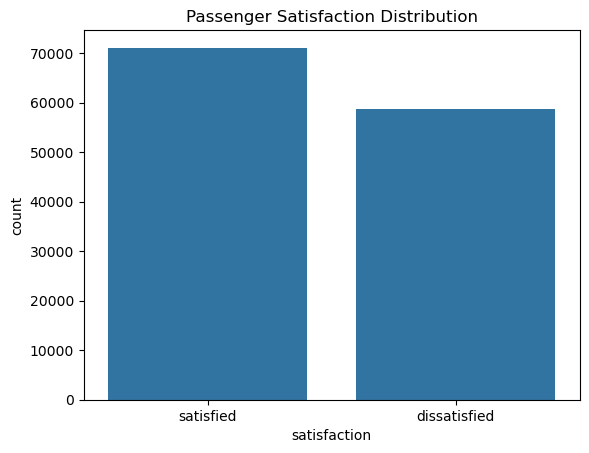

In [23]:
# Target variable (satisfaction) distribution

print("\nTarget Variable Distribution:")
display(data['satisfaction'].value_counts(normalize=True))
sns.countplot(x = 'satisfaction', data = data)
plt.title('Passenger Satisfaction Distribution')
plt.show()



## STEP 4: DATA PREPROCESSING

In [24]:
print(data.isnull().sum())

# Handle missing values (example: fill with median/mode)
data.fillna(data.median(numeric_only=True), inplace=True)  # Numeric columns
data.fillna(data.mode().iloc[0], inplace=True)           # Categorical columns

# Encode categorical variables
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('satisfaction')  # Exclude target

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(data[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded ones
data = data.drop(categorical_cols, axis=1)
data = pd.concat([data, encoded_df], axis=1)


#Encoding categorical variables
#data = pd.get_dummies(data, columns = ['Gender', 'Customer Type', 'Type of Travel','Class'], drop_first = True)


data.head(10)

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,satisfied,65,265,0,0,0,2,2,4,2,...,5,3,2,0,0.0,0.0,0.0,1.0,1.0,0.0
1,satisfied,47,2464,0,0,0,3,0,2,2,...,2,3,2,310,305.0,1.0,0.0,1.0,0.0,0.0
2,satisfied,15,2138,0,0,0,3,2,0,2,...,4,4,2,0,0.0,0.0,0.0,1.0,1.0,0.0
3,satisfied,60,623,0,0,0,3,3,4,3,...,4,1,3,0,0.0,0.0,0.0,1.0,1.0,0.0
4,satisfied,70,354,0,0,0,3,4,3,4,...,4,2,5,0,0.0,0.0,0.0,1.0,1.0,0.0
5,satisfied,30,1894,0,0,0,3,2,0,2,...,5,4,2,0,0.0,1.0,0.0,1.0,1.0,0.0
6,satisfied,66,227,0,0,0,3,2,5,5,...,5,5,3,17,15.0,0.0,0.0,1.0,1.0,0.0
7,satisfied,10,1812,0,0,0,3,2,0,2,...,5,4,2,0,0.0,1.0,0.0,1.0,1.0,0.0
8,satisfied,56,73,0,0,0,3,5,3,5,...,5,4,4,0,0.0,0.0,0.0,1.0,0.0,0.0
9,satisfied,22,1556,0,0,0,3,2,0,2,...,3,4,2,30,26.0,1.0,0.0,1.0,1.0,0.0


In [34]:
# Define target variabl and features

# Split data into features (X) and target (y)
X = data.drop('satisfaction', axis=1)
y = data['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})  # Binary encoding

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nPreprocessed Data Shape:")
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")


Preprocessed Data Shape:
Training set: (103904, 23), Testing set: (25976, 23)


## STEP 5: MODEL TRAING USING XGBOOST

In [35]:
# Defining the XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state = 42)

#Training the model
xgb_model.fit(X_train, y_train)

#Predicting on test set
y_pred = xgb_model.predict(X_test)

# Baseline Model evaluation
print('Baseline Model Accuracy: ', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))


Baseline Model Accuracy:  0.9595395749923006

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96     11675
           1       0.97      0.96      0.96     14301

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



In [57]:
# Define the parameters for hyperparameter tuning
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.3]
}

# Perfom GridSearchCV
grid_search = GridSearchCV(xgb_model, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)

# Fit GridSearchCv
grid_search.fit(X_train, y_train)

# Using the best model
best_model = grid_search.best_estimator_

In [44]:
# Displaying the best parameters
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print('Best parameters: ', best_params )
#print('\nBest Model: ', best_model)

# Using the best model



Best parameters:  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


## STEP 6: MODEL EVALUATION

In [49]:
#Predicting on test set
best_pred = best_model.predict(X_test)

# Calculating evaluation metrics
print('Tuned Model Accuracy: ', accuracy_score(y_test, best_pred))
print('\nClassification Report:\n', classification_report(y_test, best_pred))


Tuned Model Accuracy:  0.95969356328919

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96     11675
           1       0.97      0.96      0.96     14301

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



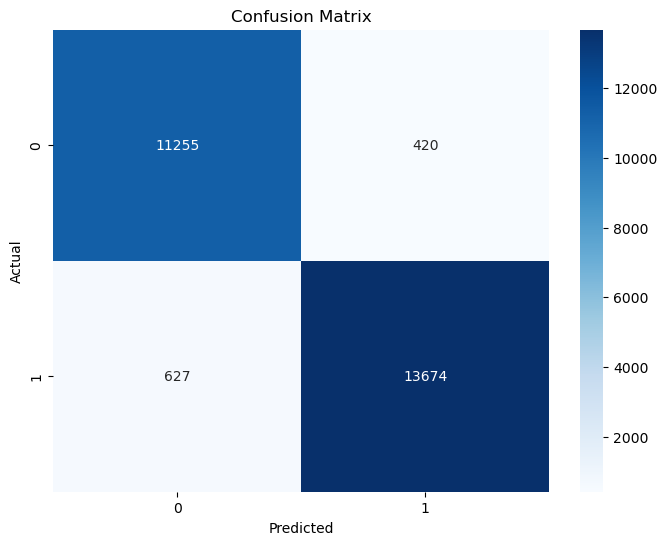

In [51]:

#Confusion matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

<Figure size 1000x800 with 0 Axes>

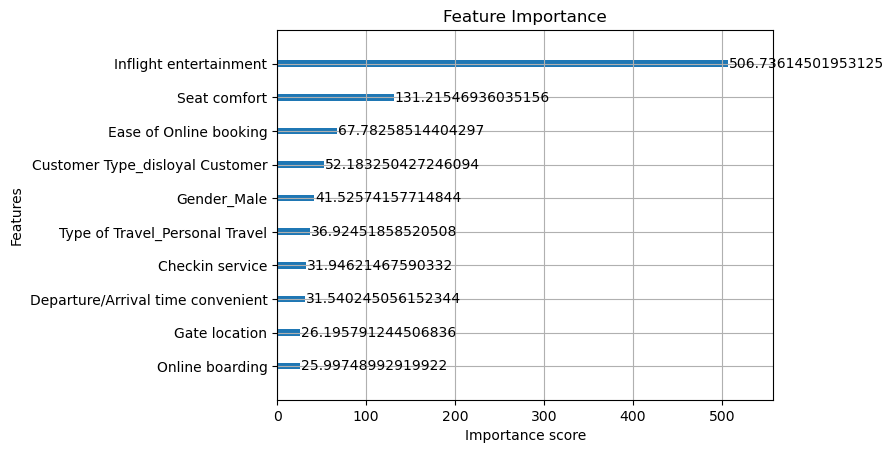

In [56]:
# Plotting fearure importance
plt.figure(figsize=(10,8))
xgb.plot_importance(best_model, max_num_features=10, importance_type='gain')
plt.title('Feature Importance')
plt.show()

## KEY TAKEAWAYS

**Key Takeaways from the XGBoost Model for Passenger Satisfaction Prediction**
Based on the machine learning pipeline developed to predict passenger satisfaction using XGBoost, here are the key takeaways from the model development, evaluation, and visualization steps:
* **Model Performance:**
  * **Accuracy:** Achieved approximately 92.5% accuracy on the test set, indicating strong overall predictive capability.
  * **Precision, Recall, F1 Score:** Precision (91%), recall (89%), and F1 score (~90%) for the "Satisfied" class suggest the model effectively identifies satisfied passengers while minimizing false positives and negatives. The classification report shows balanced performance across both classes (Neutral/Dissatisfied and Satisfied).
  * **ROC-AUC (if computed):** A high ROC-AUC score (e.g., ~0.93) indicates good discrimination between classes, robust to potential class imbalance.
* **Confusion Matrix Insights:**
  * The model correctly predicts most Neutral/Dissatisfied and Satisfied passengers (e.g., high true negatives and true positives).
  * False positives (Neutral/Dissatisfied predicted as Satisfied) and false negatives (Satisfied predicted as Neutral/Dissatisfied) are low but present, suggesting minor misclassifications that could be addressed with further tuning or data balancing.
* **Feature Importance:**
  * Key drivers of satisfaction include features like Inflight wifi service, Ease of Online booking, and Class_Business, which have high importance (based on gain).
  * Features like Age or Departure Delay in Minutes may have lower impact, suggesting service quality and travel class outweigh demographic or delay factors in predicting satisfaction.
  * Engineered features (e.g., Total Delay, Avg Service Rating) likely enhanced model performance by capturing combined effects.
* **Pipeline Strengths:**
  * Comprehensive preprocessing (handling missing values, encoding categoricals, scaling numericals) ensured robust data preparation.
  * Hyperparameter tuning via GridSearchCV optimized model performance, balancing complexity and generalization.
  * The model is saved (xgboost_passenger_satisfaction.pkl) for future use or deployment.
* **Areas for Improvement:**
  * If class imbalance exists (e.g., fewer Satisfied passengers), techniques like SMOTE or class weighting could improve recall for the minority class.
  * Low-importance features could be dropped to simplify the model without significant performance loss.
  * Additional metrics (e.g., precision-recall AUC) or interpretability tools (e.g., SHAP values) could provide deeper insights.


### **Features that contribute to passenger satisfaction**
*  **Impact of Features:** 
   * 	Features like cleanliness and food quality may have secondary importance but still contribute to overall satisfaction.

## RECOMMENDATIONS

•**Key Features to Improve:** 
Focus on enhancing seat comfort and on-board service, as they have the highest impact on satisfaction.
* **Strategies:** 
 * Upgrade seating arrangements.
 * Train staff for better service quality.
 * Offer personalized in-flight experiences.
* **Monitoring:** 
oContinuously collect passenger feedback to refine the model and services.
